Step 0, Loss 2116176154984448.0
Step 50, Loss 554700428541952.0
Step 100, Loss 412018595069952.0
Step 150, Loss 341208844992512.0


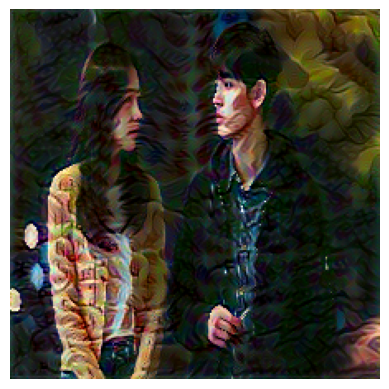

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications.vgg19 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model

# -----------------------------
# Load and Preprocess Image
# -----------------------------

def load_img(path):
    img = image.load_img(path, target_size=(224,224))
    img = image.img_to_array(img)
    img = np.expand_dims(img, axis=0)
    img = preprocess_input(img)
    return tf.convert_to_tensor(img)

content_image = load_img("content.png")
style_image = load_img("style.jpg")

# -----------------------------
# Load Pretrained VGG19
# -----------------------------

vgg = VGG19(include_top=False, weights='imagenet')
vgg.trainable = False

# Content and Style Layers
content_layer = ['block5_conv2']
style_layers = [
    'block1_conv1',
    'block2_conv1',
    'block3_conv1',
    'block4_conv1',
    'block5_conv1'
]

# -----------------------------
# Feature Extraction Model
# -----------------------------

outputs = [vgg.get_layer(name).output for name in style_layers + content_layer]
model = Model(vgg.input, outputs)

# -----------------------------
# Gram Matrix for Style
# -----------------------------

def gram_matrix(tensor):
    channels = int(tensor.shape[-1])
    a = tf.reshape(tensor, [-1, channels])
    gram = tf.matmul(a, a, transpose_a=True)
    return gram

# -----------------------------
# Content Loss
# -----------------------------

def content_loss(base, target):
    return tf.reduce_mean(tf.square(base - target))

# -----------------------------
# Style Loss
# -----------------------------

def style_loss(base, target):
    gram_base = gram_matrix(base)
    gram_target = gram_matrix(target)
    return tf.reduce_mean(tf.square(gram_base - gram_target))

# -----------------------------
# Extract Features
# -----------------------------

style_targets = model(style_image)[:len(style_layers)]
content_target = model(content_image)[len(style_layers):]

# -----------------------------
# Total Loss
# -----------------------------

style_weight = 1e-2
content_weight = 1e4

def total_loss(outputs):

    style_outputs = outputs[:len(style_layers)]
    content_outputs = outputs[len(style_layers):]

    s_loss = 0
    c_loss = 0

    for s, t in zip(style_outputs, style_targets):
        s_loss += style_loss(s[0], t[0])

    for c, t in zip(content_outputs, content_target):
        c_loss += content_loss(c[0], t[0])

    total = style_weight*s_loss + content_weight*c_loss

    return total

# -----------------------------
# Image Optimization
# -----------------------------

generated_image = tf.Variable(content_image)

optimizer = tf.optimizers.Adam(learning_rate=0.5)

@tf.function
def train_step():

    with tf.GradientTape() as tape:

        outputs = model(generated_image)
        loss = total_loss(outputs)

    grad = tape.gradient(loss, generated_image)
    optimizer.apply_gradients([(grad, generated_image)])

    return loss

# -----------------------------
# Training Loop
# -----------------------------

epochs = 200

for i in range(epochs):
    loss = train_step()

    if i % 50 == 0:
        print(f"Step {i}, Loss {loss}")

# -----------------------------
# Display Output Image
# -----------------------------

def deprocess_img(img):

    img = img.numpy().reshape((224,224,3))

    img[:,:,0] += 103.939
    img[:,:,1] += 116.779
    img[:,:,2] += 123.68

    img = img[:,:,::-1]
    img = np.clip(img,0,255).astype('uint8')

    return img

result = deprocess_img(generated_image)

plt.imshow(result)
plt.axis("off")
plt.show()